# PPI network analysis

Input: `top500_features.csv` with columns `GEX`, `METH`, and `CNV`.

Outputs are saved in `ppi_outputs/`.

In [1]:
from pathlib import Path
from io import StringIO
import re
import warnings

import numpy as np
import pandas as pd
import requests
import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

INPUT = Path("top500_features.csv")
OUT = Path("ppi_outputs")
OUT.mkdir(exist_ok=True)

SPECIES = 9606
REQUIRED_SCORE = 700
TOP_N = 100
STRING_API = "https://string-db.org/api"
CALLER_ID = "KIRC_multiomics_ppi"

In [2]:
top = pd.read_csv(INPUT)
top.columns = top.columns.str.strip()
top["rank"] = np.arange(1, len(top) + 1)

required = {"GEX", "METH", "CNV"}
missing = required - set(top.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

display(top.head())
print(top[["GEX", "METH", "CNV"]].notna().sum())

,GEX,METH,CNV,rank
0,MIF,cg23097686,FAM174A,1
1,DGCR5,cg04456219,ST8SIA4,2
2,EEF1G,cg02326386,SACM1L,3
3,AQP2,cg01702055,SLCO4C1,4
4,UBD,cg11201447,SLC25A46,5


GEX     500
METH    500
CNV     500
dtype: int64


## Map methylation probes

In [3]:
def clean_gene(x):
    if pd.isna(x):
        return None
    x = str(x).strip().upper()
    if x in {"", "NAN", "NONE", "NA", "NULL", "."}:
        return None
    return x

def split_genes(x):
    if pd.isna(x):
        return []
    genes = []
    for g in re.split(r"[;,|]", str(x)):
        g = g.strip()
        if not g:
            continue
        g = g.split(":")[0].split()[0]
        g = clean_gene(g)
        if g:
            genes.append(g)
    return sorted(set(genes))

def first_col(df, options):
    lookup = {c.lower(): c for c in df.columns}
    for c in options:
        if c in df.columns:
            return c
        if c.lower() in lookup:
            return lookup[c.lower()]
    return None

probe_cols = ["Probe_ID", "probeID", "ProbeID", "IlmnID", "Name", "ID", "CpG"]
gene_cols = ["gene_HGNC", "geneNames", "genesUniq", "UCSC_RefGene_Name", "Gene_Symbol", "gene"]

ann_urls = {
    "HM450": "https://zhouserver.research.chop.edu/InfiniumAnnotation/current/HM450/HM450.hg38.manifest.gencode.v36.tsv.gz",
    "EPIC": "https://zhouserver.research.chop.edu/InfiniumAnnotation/current/EPIC/EPIC.hg38.manifest.gencode.v36.tsv.gz",
}

def load_probe_map(probes):
    probes = set(map(str, probes))
    local = Path("meth_probe_to_gene.csv")

    if local.exists():
        tables = [("local", pd.read_csv(local, dtype=str))]
    else:
        tables = []
        for name, url in ann_urls.items():
            try:
                tables.append((name, pd.read_csv(url, sep="\t", compression="gzip", dtype=str, low_memory=False)))
            except Exception as e:
                print(f"{name} annotation failed: {e}")

    mapped = []
    for name, ann in tables:
        ann.columns = ann.columns.str.strip()
        probe_col = first_col(ann, probe_cols)
        gene_col = first_col(ann, gene_cols)
        if probe_col is None or gene_col is None:
            print(f"{name}: probe/gene column not found")
            continue

        tmp = ann.loc[ann[probe_col].isin(probes), [probe_col, gene_col]].copy()
        tmp.columns = ["CpG", "gene_raw"]
        tmp["gene"] = tmp["gene_raw"].apply(split_genes)
        tmp = tmp.explode("gene").dropna(subset=["gene"])
        tmp["source"] = name
        mapped.append(tmp[["CpG", "gene", "source"]].drop_duplicates())

    if not mapped:
        return pd.DataFrame(columns=["CpG", "gene", "source"])
    return pd.concat(mapped, ignore_index=True).drop_duplicates()

meth_probes = top["METH"].dropna().astype(str).str.strip().unique()
meth_map = load_probe_map(meth_probes)
meth_map.to_csv(OUT / "meth_probe_to_gene.csv", index=False)

print(f"Methylation probes mapped: {meth_map['CpG'].nunique()} / {len(meth_probes)}")
print(f"Mapped methylation genes: {meth_map['gene'].nunique()}")
display(meth_map.head())

Methylation probes mapped: 410 / 500
Mapped methylation genes: 452


,CpG,gene,source
0,cg09364122,ISG15,HM450
1,cg01961086,PRDM16,HM450
2,cg13434489,PRDM16,HM450
3,cg15819225,TP73,HM450
4,cg15819225,TP73-AS3,HM450


In [4]:
gex = pd.DataFrame({
    "feature": top["GEX"],
    "gene": top["GEX"].apply(clean_gene),
    "omic": "GEX",
    "rank": top["rank"],
})

cnv = pd.DataFrame({
    "feature": top["CNV"],
    "gene": top["CNV"].apply(clean_gene),
    "omic": "CNV",
    "rank": top["rank"],
})

meth = top[["METH", "rank"]].copy()
meth["METH"] = meth["METH"].astype(str).str.strip()
meth = meth.merge(meth_map, left_on="METH", right_on="CpG", how="inner")
meth = meth.rename(columns={"METH": "feature"})
meth["omic"] = "METH"
meth = meth[["feature", "gene", "omic", "rank"]]

features = pd.concat([gex, meth, cnv], ignore_index=True)
features = features.dropna(subset=["gene"]).drop_duplicates()
features.to_csv(OUT / "top_features_gene_level_long.csv", index=False)

display(features.groupby("omic")["gene"].nunique().reset_index(name="unique_genes"))
print("Total unique genes:", features["gene"].nunique())

,omic,unique_genes
0,CNV,500
1,GEX,500
2,METH,452


Total unique genes: 1421


## STRING queries

In [5]:
def string_post(endpoint, ids, **extra):
    ids = sorted(set([x for x in ids if isinstance(x, str) and x.strip()]))
    if not ids:
        return pd.DataFrame()

    params = {
        "identifiers": "\r".join(ids),
        "species": SPECIES,
        "caller_identity": CALLER_ID,
        **extra,
    }
    r = requests.post(f"{STRING_API}/tsv/{endpoint}", data=params, timeout=180)
    if r.status_code == 404 or not r.text.strip():
        return pd.DataFrame()
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text), sep="\t")

def map_string_ids(genes, label):
    out = string_post("get_string_ids", genes, limit=1, echo_query=1)
    if not out.empty:
        out["set"] = label
    return out

maps = []
for omic in ["GEX", "METH", "CNV"]:
    genes = features.loc[features["omic"] == omic, "gene"].unique()
    m = map_string_ids(genes, omic)
    maps.append(m)
    print(f"{omic}: {len(genes)} genes, {m['queryItem'].nunique() if not m.empty else 0} STRING-mapped")

all_genes = features["gene"].unique()
m_all = map_string_ids(all_genes, "combined")
maps.append(m_all)
mapping = pd.concat(maps, ignore_index=True)
mapping.to_csv(OUT / "string_identifier_mapping_all_sets.csv", index=False)

GEX: 500 genes, 495 STRING-mapped
METH: 452 genes, 328 STRING-mapped
CNV: 500 genes, 495 STRING-mapped


In [6]:
def string_ids_for(genes):
    sub = mapping[mapping["queryItem"].isin(set(genes))]
    return sub["stringId"].dropna().unique().tolist()

def get_network(genes, label):
    ids = string_ids_for(genes)
    edges = string_post(
        "network",
        ids,
        required_score=REQUIRED_SCORE,
        network_type="functional",
        add_nodes=0,
    )
    if not edges.empty:
        edges["set"] = label
    return edges

edges_by_set = {}
for omic in ["GEX", "METH", "CNV"]:
    genes = features.query("omic == @omic and rank <= @TOP_N")["gene"].unique()
    edges = get_network(genes, f"{omic}_top{TOP_N}")
    edges_by_set[omic] = edges
    edges.to_csv(OUT / f"string_edges_{omic}_top{TOP_N}.csv", index=False)
    print(f"{omic}: {len(genes)} input genes, {len(edges)} edges")

genes_combined = features.query("rank <= @TOP_N")["gene"].unique()
edges_combined = get_network(genes_combined, f"combined_top{TOP_N}")
edges_combined.to_csv(OUT / f"string_edges_combined_top{TOP_N}_each_omic.csv", index=False)
print(f"combined: {len(genes_combined)} input genes, {len(edges_combined)} edges")

GEX: 100 input genes, 42 edges
METH: 96 input genes, 8 edges
CNV: 100 input genes, 13 edges
combined: 294 input genes, 98 edges


## Network plot

,gene,degree,omic_source
8,UQCRFS1,6,GEX
7,NDUFS2,6,GEX
1,KCNJ1,6,GEX
64,RPL21,6,GEX
3,SLC12A1,6,GEX
2,SLC12A3,5,GEX
22,SRP19,5,CNV
4,UQCRC1,4,CNV
6,NDUFA4,4,GEX
90,CLCNKB,4,GEX


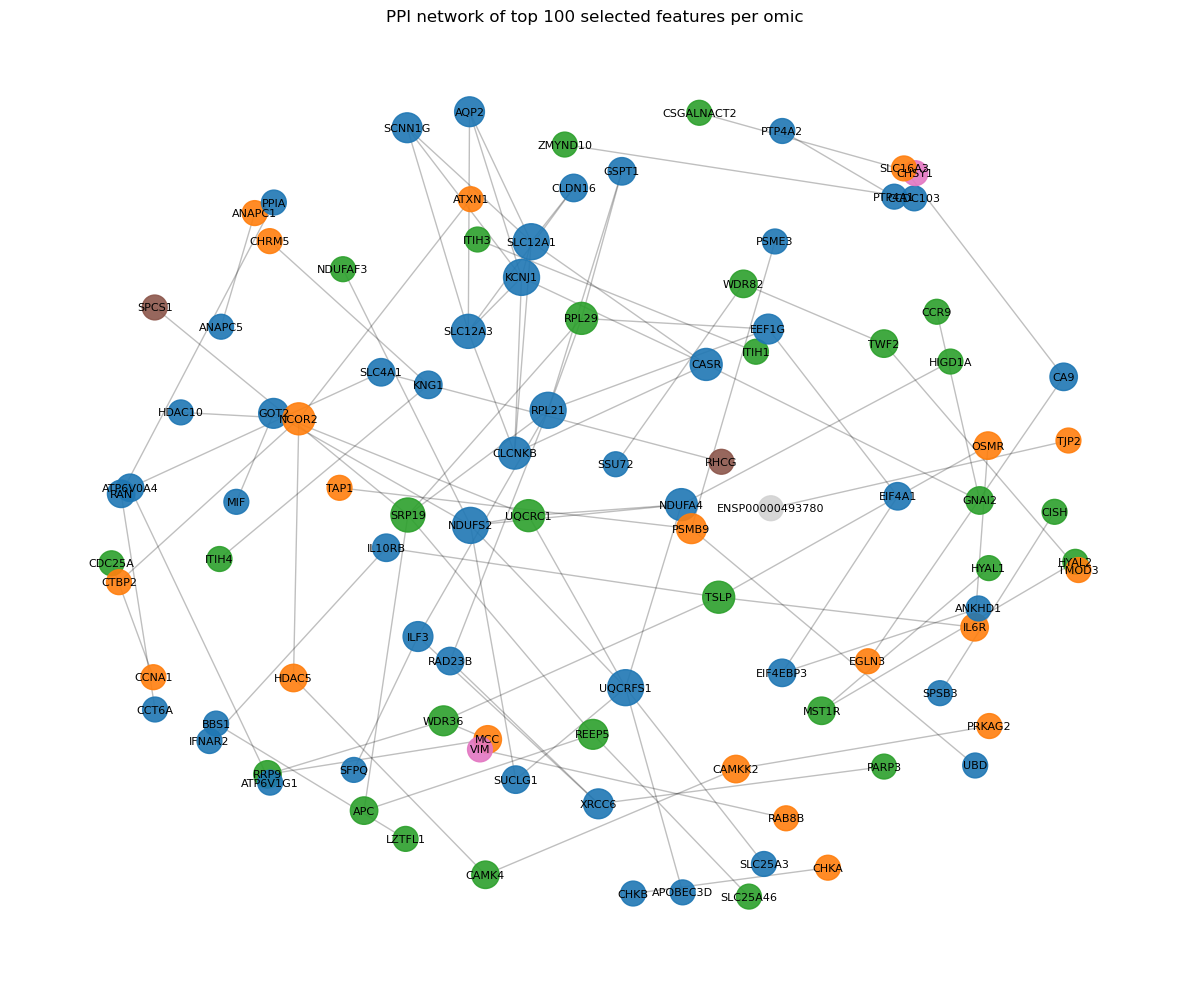

Nodes: 100
Edges: 98


In [7]:
def build_graph(edges):
    G = nx.Graph()
    if edges.empty:
        return G
    for _, r in edges.iterrows():
        a = str(r["preferredName_A"]).upper()
        b = str(r["preferredName_B"]).upper()
        G.add_edge(a, b, weight=float(r["score"]))
    return G

def omic_source_table(features):
    return features.groupby("gene")["omic"].apply(lambda x: "+".join(sorted(set(x)))).to_dict()

G = build_graph(edges_combined)
source = omic_source_table(features)
degree = dict(G.degree())

hub = pd.DataFrame({
    "gene": list(G.nodes()),
    "degree": [degree[g] for g in G.nodes()],
    "omic_source": [source.get(g, "Unknown") for g in G.nodes()],
}).sort_values("degree", ascending=False)

hub.to_csv(OUT / "ppi_hub_genes_combined_network.csv", index=False)
display(hub.head(15))

colors = {
    "GEX": "#1f77b4",
    "METH": "#ff7f0e",
    "CNV": "#2ca02c",
    "GEX+METH": "#9467bd",
    "CNV+GEX": "#8c564b",
    "CNV+METH": "#e377c2",
    "CNV+GEX+METH": "#d62728",
    "Unknown": "lightgrey",
}

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.55)

nx.draw_networkx_edges(G, pos, alpha=0.25)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=[colors.get(source.get(n, "Unknown"), "lightgrey") for n in G.nodes()],
    node_size=[250 + 70 * degree[n] for n in G.nodes()],
    alpha=0.9,
)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title(f"PPI network of top {TOP_N} selected features per omic")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUT / f"ppi_network_combined_top{TOP_N}_each_omic.png", dpi=300, bbox_inches="tight")
plt.show()

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

## Enrichment and summary

In [8]:
def ppi_enrichment(genes, label):
    ids = string_ids_for(genes)
    out = string_post("ppi_enrichment", ids, required_score=REQUIRED_SCORE)
    if not out.empty:
        out["set"] = label
    return out

def functional_enrichment(genes, label):
    ids = string_ids_for(genes)
    out = string_post("enrichment", ids)
    if not out.empty:
        out["set"] = label
    return out

ppi_rows, enr_rows = [], []
for omic in ["GEX", "METH", "CNV"]:
    genes = features.loc[features["omic"] == omic, "gene"].unique()
    ppi_rows.append(ppi_enrichment(genes, omic))
    enr_rows.append(functional_enrichment(genes, omic))

ppi_rows.append(ppi_enrichment(all_genes, "combined"))
enr_rows.append(functional_enrichment(all_genes, "combined"))

ppi = pd.concat([x for x in ppi_rows if not x.empty], ignore_index=True)
enr = pd.concat([x for x in enr_rows if not x.empty], ignore_index=True)

ppi.to_csv(OUT / "string_ppi_enrichment_by_omic.csv", index=False)
enr.to_csv(OUT / "string_functional_enrichment_all_sets.csv", index=False)

display(ppi)
display(enr.head(20))

,number_of_nodes,number_of_edges,average_node_degree,local_clustering_coefficient,expected_number_of_edges,p_value,set
0,495,833,3.37,0.382,459,0.000000e+00,GEX
1,328,123,0.75,0.235,73,5.940000e-08,METH
2,495,223,0.90,0.271,167,2.100000e-05,CNV
3,1286,2192,3.41,0.353,1790,0.000000e+00,combined


,category,term,number_of_genes,number_of_genes_in_background,ncbiTaxonId,inputGenes,preferredNames,p_value,fdr,description,set
0,COMPARTMENTS,GOCC:0032991,220,5325,9606,"9606.ENSP00000006777,9606.ENSP00000081029,9606...","RHBDD2,MRPS35,PSMC4,PSMD8,SNRPD3,APOBEC3D,IL2R...",1.940000e-16,4.470000e-13,Protein-containing complex,GEX
1,COMPARTMENTS,GOCC:0005737,293,8195,9606,"9606.ENSP00000006777,9606.ENSP00000081029,9606...","RHBDD2,MRPS35,PSMC4,AQP2,SLC22A4,SPG21,PSMD8,M...",5.750000e-15,6.610000e-12,Cytoplasm,GEX
2,COMPARTMENTS,GOCC:0043227,314,9083,9606,"9606.ENSP00000006777,9606.ENSP00000081029,9606...","RHBDD2,MRPS35,PSMC4,AQP2,SLC22A4,SPG21,PSMD8,M...",1.480000e-14,1.140000e-11,Membrane-bounded organelle,GEX
3,COMPARTMENTS,GOCC:0000502,19,62,9606,"9606.ENSP00000157812,9606.ENSP00000215071,9606...","PSMC4,PSMD8,PSMB7,PSMD11,PSMA5,PSMB4,PSME3,PSM...",6.610000e-14,3.800000e-11,Proteasome complex,GEX
4,COMPARTMENTS,GOCC:0005622,368,11512,9606,"9606.ENSP00000006777,9606.ENSP00000081029,9606...","RHBDD2,MRPS35,PSMC4,AQP2,SLC22A4,MLF2,SPG21,PS...",2.050000e-13,9.410000e-11,Intracellular,GEX
5,COMPARTMENTS,GOCC:1905369,21,90,9606,"9606.ENSP00000157812,9606.ENSP00000215071,9606...","PSMC4,PSMD8,PSMB7,PSMD11,PSMA5,PIGT,PSMB4,PSME...",2.980000e-13,1.140000e-10,Endopeptidase complex,GEX
6,COMPARTMENTS,GOCC:1902494,95,1710,9606,"9606.ENSP00000006777,9606.ENSP00000157812,9606...","RHBDD2,PSMC4,PSMD8,SNRPD3,HDAC10,SPCS1,INO80B,...",5.740000e-13,1.890000e-10,Catalytic complex,GEX
7,COMPARTMENTS,GOCC:0043226,333,10113,9606,"9606.ENSP00000006777,9606.ENSP00000081029,9606...","RHBDD2,MRPS35,PSMC4,AQP2,SLC22A4,SPG21,PSMD8,M...",9.480000e-13,2.730000e-10,Organelle,GEX
8,COMPARTMENTS,GOCC:1905368,24,136,9606,"9606.ENSP00000157812,9606.ENSP00000215071,9606...","PSMC4,PSMD8,SPCS1,PSMB7,PSMD11,PSMA5,PIGT,PSMB...",1.210000e-12,3.090000e-10,Peptidase complex,GEX
9,COMPARTMENTS,GOCC:0043229,320,9609,9606,"9606.ENSP00000006777,9606.ENSP00000081029,9606...","RHBDD2,MRPS35,PSMC4,AQP2,SLC22A4,SPG21,PSMD8,M...",1.570000e-12,3.620000e-10,Intracellular organelle,GEX


In [9]:
def graph_stats(label, edges):
    g = build_graph(edges)
    return {
        "network": label,
        "nodes": g.number_of_nodes(),
        "edges": g.number_of_edges(),
        "components": nx.number_connected_components(g) if g.number_of_nodes() else 0,
        "largest_component": max([len(c) for c in nx.connected_components(g)]) if g.number_of_nodes() else 0,
        "average_degree": np.mean([d for _, d in g.degree()]) if g.number_of_nodes() else 0,
    }

network_summary = pd.DataFrame(
    [graph_stats(k, v) for k, v in edges_by_set.items()] +
    [graph_stats("combined", edges_combined)]
)
network_summary.to_csv(OUT / "ppi_network_summary_by_set.csv", index=False)

summary = f"""
# PPI summary

Methylation probes mapped: {meth_map['CpG'].nunique()} / {len(meth_probes)}
Methylation-mapped genes: {meth_map['gene'].nunique()}

## Unique genes by omic
{features.groupby('omic')['gene'].nunique().reset_index(name='unique_genes').to_markdown(index=False)}

## Network summary
{network_summary.to_markdown(index=False)}

## Top hubs
{hub.head(15).to_markdown(index=False)}
"""

(OUT / "ppi_summary_for_report.md").write_text(summary)
print(summary)


# PPI summary

Methylation probes mapped: 410 / 500
Methylation-mapped genes: 452

## Unique genes by omic
| omic   |   unique_genes |
|:-------|---------------:|
| CNV    |            500 |
| GEX    |            500 |
| METH   |            452 |

## Network summary
| network   |   nodes |   edges |   components |   largest_component |   average_degree |
|:----------|--------:|--------:|-------------:|--------------------:|-----------------:|
| GEX       |      37 |      42 |            7 |                  10 |          2.27027 |
| METH      |      14 |       8 |            6 |                   4 |          1.14286 |
| CNV       |      18 |      13 |            6 |                   6 |          1.44444 |
| combined  |     100 |      98 |           23 |                  17 |          1.96    |

## Top hubs
| gene    |   degree | omic_source   |
|:--------|---------:|:--------------|
| UQCRFS1 |        6 | GEX           |
| NDUFS2  |        6 | GEX           |
| KCNJ1   |        6 | 